# DP-SGD against a non-private baseline, on Criteo

This notebook compares DP-SGD (Abadi et al., *Deep Learning with Differential
Privacy*, 2016, [arXiv:1607.00133](https://arxiv.org/abs/1607.00133)) against
non-private SGD on Criteo click-through data. Both arms fit the same logistic
regression over the same number of optimizer steps; the private arm runs at
ε = 3, δ = 1e-6.

What is fixed across both arms, and why:

- the same per-sample loss, `per_sample_bce_loss`;
- the same model and the **same initialization**, `init_params(jax.random.key(0), d)`
  — one starting point, not one per arm;
- the same optimizer object, `updates.sgd(lr)`, with the arm's own tuned `lr`;
- the same split, the same `feature_norm_bound = R = 2.0`, the same evaluation
  set, the same threshold rule;
- the same **number of optimizer steps**. Privacy composes over steps, not over
  epochs, so steps are the axis on which the two arms are commensurable.

**Important difference:** DP-SGD draws Poisson lots of expected size `L`; plain
SGD draws shuffled epochs of exact size `B`. That difference is forced.

In [1]:
import time
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting.sampling import (
    PoissonGaussianSchedule,
    calibrate_noise_multiplier,
    poisson_gaussian_epsilon,
)
from dimma.algorithms.dp_sgd import train as dp_sgd
from dimma.algorithms.sgd import train as sgd
from dimma.core import updates
from dimma.datasets.criteo import load_criteo
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
    reliability_curve,
)
from dimma.metrics.decomposition import log_loss_decomposition
from dimma.metrics.operating_point import best_f1_threshold, confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward, init_params
from dimma.models.losses import per_sample_bce_loss

# The budget, fixed before anything is fitted.
TARGET_EPSILON = 3.0
TARGET_DELTA = 1e-6 # Could be changed to 1/n**(1.1)

# The step budget. Both arms take exactly this many optimizer steps, and this
# is the composition count the noise multiplier is calibrated against.
STEPS = 10_000

# ADR-0012's R. Fixed a priori, never read off the data. Identical in both arms.
FEATURE_NORM_BOUND = 2.0

# Seeds: fundamental for pytree work
INIT_SEED = 0
BASE_SEED = 20260809

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

# One palette for every figure below.
SERIES = {"plain SGD": "#2a78d6", "DP-SGD": "#eb6834"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.markersize": 6.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 10,
})

jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


## 1. Data

Criteo click-through data, loaded by `load_criteo`; the preprocessing it
applied is recorded in the metadata printed below. Every row is capped to
ℓ2 norm `R = 2.0`, identically for both arms. The 800,000-row training split is
cut deterministically into 700,000 training rows and 100,000 validation rows,
and the test split is not read until section 6.

In [2]:
split = load_criteo(features="all", preprocess=True, standardize=True,
                    download=False, seed=0,
                    device=DEVICE,
                    feature_norm_bound=FEATURE_NORM_BOUND)

n_all, n_features = split.x_train.shape

# One deterministic cut of the training split. Not a resample: a permutation
# with a fixed seed, held out once and never re-drawn.
holdout = np.random.default_rng(BASE_SEED).permutation(n_all)
val_index = jnp.asarray(holdout[:100_000])
train_index = jnp.asarray(holdout[100_000:])

X_TRAIN, Y_TRAIN = split.x_train[train_index], split.y_train[train_index]
X_VAL, Y_VAL = split.x_train[val_index], split.y_train[val_index]
X_TEST, Y_TEST = split.x_test, split.y_test

n_train = X_TRAIN.shape[0]
base_rate = float(Y_TEST.mean())

print(f"train {X_TRAIN.shape}   val {X_VAL.shape}   test {X_TEST.shape}")
print(f"label base rate: {float(Y_TRAIN.mean()):.4f} train, "
      f"{float(Y_VAL.mean()):.4f} val, {base_rate:.4f} test")
print(f"PR-AUC floor (a random ranking scores the base rate): {base_rate:.4f}")
print(f"arrays live on: {list(X_TRAIN.devices())}")
print()
print(f"enforced feature norm bound R = "
      f"{split.metadata['feature_norm_bound']}")
print()
print(split.metadata["preprocessing"])

criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 2.0, one record at a time.


train (700000, 39)   val (100000, 39)   test (200000, 39)
label base rate: 0.2508 train, 0.2523 val, 0.2520 test
PR-AUC floor (a random ranking scores the base rate): 0.2520
arrays live on: [CudaDevice(id=0)]

enforced feature norm bound R = 2.0

39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 2.0, one record at a time.


## 2. Shared machinery: one evaluator, one runner per arm

Everything the two arms share is written once here: one evaluator, and one
runner shape per arm. Four numbers are reported throughout.

- **Log-loss** — the objective both arms descend.
- **ECE**, at 15 equal-mass bins — per-example clipping, not the noise, is the
  documented cause of miscalibration under DP (Zhang et al., *A Closer Look at
  the Calibration of Differentially Private Learners*,
  [arXiv:2210.08248](https://arxiv.org/abs/2210.08248)), which is why the sweep
  below is over `C`.
- **Normalized entropy** and the **calibration ratio** — log-loss against the
  base rate, and observed clicks over predicted clicks.
- **PR-AUC** — the ranking read, floored at the base rate.

In [3]:
N_BINS = 15    # equal-mass bins for every ECE below
Y_VAL_NP = np.asarray(Y_VAL, dtype=np.float64)


class Eval(NamedTuple):
    """What one run is scored on, on whichever split it was pointed at.

    All three are threshold-free. The operating point arrives in section 6
    and nothing here depends on it.
    """

    loss: float
    pr_auc: float
    ece: float


def scores(params, x):
    """Logits for a whole array. `forward` is a single-example function."""
    return np.asarray(jax.vmap(forward, in_axes=(None, 0))(params, x))


def probabilities(logits):
    """The logits squashed once, so every number below reads one array.

    `dimma.metrics` takes probabilities and raises on anything else, so
    this is the notebook's single conversion point.
    """
    return np.asarray(jax.nn.sigmoid(jnp.asarray(logits)), dtype=np.float64)


def evaluate_at(params, x, y):
    """Score one parameter set on an arbitrary split. Guards divergence.

    The metrics raise on non-finite input rather than returning nan, so the
    guard stays in front of them: a diverged run has no scores, not bad
    ones.
    """
    logits = scores(params, x)
    if not np.all(np.isfinite(logits)):
        return Eval(float("nan"), float("nan"), float("nan"))
    probs, labels = probabilities(logits), np.asarray(y, dtype=np.float64)
    return Eval(loss=log_loss(probs, labels),
                pr_auc=pr_curve(probs, labels).average_precision,
                ece=expected_calibration_error(probs, labels, n_bins=N_BINS))


def show_confusion(confusion, title, threshold):
    """The 2x2 as a table — four numbers do not need a chart."""
    tn, fp, fn, tp = confusion
    print(f"{title}")
    print(f"                 predicted no    predicted click")
    print(f"  actual no      {tn:>12,}    {fp:>15,}")
    print(f"  actual click   {fn:>12,}    {tp:>15,}")
    precision = tp / (tp + fp) if tp + fp else float("nan")
    recall = tp / (tp + fn) if tp + fn else float("nan")
    print(f"  precision {precision:.4f}   TPR (recall) {recall:.4f}   "
          f"(at threshold p >= {threshold:.4f})")

In [4]:
def fresh_params():
    """The one starting point, shared by both arms and every configuration."""
    return init_params(jax.random.key(INIT_SEED), n_features)


def fit_sgd(*, learning_rate, batch_size, steps=STEPS, seed_index=0,
            params=None, rng=None):
    """Plain SGD: shuffled epochs, no clipping, no noise, no epsilon."""
    params = fresh_params() if params is None else params
    rng = np.random.default_rng([BASE_SEED, seed_index]) if rng is None else rng
    return sgd.train(
        per_sample_bce_loss, params, updates.sgd(learning_rate),
        X_TRAIN, Y_TRAIN, rng,
        steps=steps, batch_size=batch_size,
    ), rng


def fit_dp_sgd(*, learning_rate, expected_batch_size, clip_norm,
               noise_multiplier, steps=STEPS, seed_index=0, chunk=0,
               params=None, rng=None):
    """DP-SGD: Poisson lots, per-sample clipping to `clip_norm`, Gaussian noise."""
    params = fresh_params() if params is None else params
    rng = np.random.default_rng([BASE_SEED, seed_index]) if rng is None else rng
    key = jax.random.fold_in(jax.random.key(BASE_SEED + seed_index), chunk)
    return dp_sgd.train(
        per_sample_bce_loss, params, updates.sgd(learning_rate),
        X_TRAIN, Y_TRAIN, key, rng,
        steps=steps, expected_batch_size=expected_batch_size,
        clip_norm=clip_norm, noise_multiplier=noise_multiplier,
    ), rng

## 3. Calibrating the budget

`calibrate_noise_multiplier` runs the accountant backwards: given a target
`(ε, δ)` and the shape of the run — `q = L / n` with `n = 700,000`, and
`T = STEPS = 10,000` steps — it returns the smallest noise multiplier that
meets the budget. `L` is part of that shape, so the sweep needs one multiplier
per expected lot size.

The clipping norm does not enter: sensitivity is `S = C` by construction and
the noise scales with it, so the multiplier is the same at every `C`. **The ε
is RDP's** (ADR-0011), and the method is held fixed at `"rdp"` throughout.

In [5]:
def sigma_for(expected_batch_size, steps=STEPS, epsilon=TARGET_EPSILON):
    """The smallest noise multiplier meeting (epsilon, delta) for this shape."""
    q = expected_batch_size / n_train
    return calibrate_noise_multiplier(
        lambda multiplier: [PoissonGaussianSchedule(q, multiplier, steps)],
        epsilon, TARGET_DELTA,
    )


DP_BATCH_GRID = [256, 1024]
SIGMA = {}

t0 = time.time()
for L in DP_BATCH_GRID:
    s = sigma_for(L)
    spent = poisson_gaussian_epsilon(L / n_train, s, STEPS, TARGET_DELTA)
    SIGMA[L] = s
    assert spent <= TARGET_EPSILON + 1e-9
    print(f"L={L:<6} q={L / n_train:.6f}  sigma={s:.6f}  "
          f"-> epsilon={spent:.6f} at delta={TARGET_DELTA} "
          f"over {STEPS:,} steps")
print(f"\ncalibrated in {time.time() - t0:.1f}s (method='rdp')")

L=256    q=0.000366  sigma=0.583168  -> epsilon=2.999998 at delta=1e-06 over 10,000 steps


L=1024   q=0.001463  sigma=0.699134  -> epsilon=2.999999 at delta=1e-06 over 10,000 steps

calibrated in 0.4s (method='rdp')


## 4. Hyperparameter search, both arms, selected on validation log-loss

Both arms are swept over grids of comparable size, and each keeps its own best
configuration.

- **Plain SGD** — learning rate `[0.01 … 3.0]` × batch size `[64, 256, 1024]`,
  6 × 3 = 18 runs.
- **DP-SGD** — learning rate `[0.03 … 10.0]` × clipping norm `[0.1, 0.3, 1.0]` ×
  expected lot size `[256, 1024]`, 6 × 3 × 2 = 36 runs. The clipping norm is
  the axis the baseline does not have, and it interacts with the learning rate:
  clipping caps the update at `lr · C`, so what matters is roughly their
  product, which is why this grid reaches `lr = 10`.

**The selection rule, stated once and applied identically to both arms: the
lowest validation log-loss.** Every run takes the same `STEPS = 10,000` steps
the calibration assumed. The search itself is unaccounted; the reported ε
covers the selected run only.

In [6]:
SGD_LR_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
SGD_BATCH_GRID = [64, 256, 1024]

sgd_sweep = []
t0 = time.time()
for index, batch in enumerate(SGD_BATCH_GRID):
    for j, lr in enumerate(SGD_LR_GRID):
        seed_index = index * len(SGD_LR_GRID) + j
        params, _ = fit_sgd(learning_rate=lr, batch_size=batch,
                            seed_index=seed_index)
        ev = evaluate_at(params, X_VAL, Y_VAL)
        sgd_sweep.append(dict(lr=lr, batch=batch, loss=ev.loss,
                              pr_auc=ev.pr_auc, seed_index=seed_index))
        print(f"  B={batch:<6} lr={lr:<7} val log-loss={ev.loss:.4f}  "
              f"val PR-AUC={ev.pr_auc:.4f}")
print(f"\nplain SGD sweep: {len(sgd_sweep)} runs in {time.time() - t0:.0f}s")

  B=64     lr=0.01    val log-loss=0.5138  val PR-AUC=0.4400


  B=64     lr=0.03    val log-loss=0.5123  val PR-AUC=0.4450


  B=64     lr=0.1     val log-loss=0.5115  val PR-AUC=0.4488


  B=64     lr=0.3     val log-loss=0.5125  val PR-AUC=0.4480


  B=64     lr=1.0     val log-loss=0.5138  val PR-AUC=0.4435


...

  B=1024   lr=0.03    val log-loss=0.5122  val PR-AUC=0.4455


  B=1024   lr=0.1     val log-loss=0.5113  val PR-AUC=0.4499


  B=1024   lr=0.3     val log-loss=0.5112  val PR-AUC=0.4510


  B=1024   lr=1.0     val log-loss=0.5112  val PR-AUC=0.4519


  B=1024   lr=3.0     val log-loss=0.5118  val PR-AUC=0.4492

plain SGD sweep: 18 runs in 237s


In [7]:
DP_LR_GRID = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
DP_CLIP_GRID = [0.1, 0.3, 1.0]

dp_sweep = []
t0 = time.time()
counter = 0
for L in DP_BATCH_GRID:
    for clip in DP_CLIP_GRID:
        for lr in DP_LR_GRID:
            params, _ = fit_dp_sgd(learning_rate=lr, expected_batch_size=L,
                                   clip_norm=clip, noise_multiplier=SIGMA[L],
                                   seed_index=counter)
            ev = evaluate_at(params, X_VAL, Y_VAL)
            dp_sweep.append(dict(lr=lr, clip=clip, batch=L, loss=ev.loss,
                                 pr_auc=ev.pr_auc, seed_index=counter))
            print(f"  L={L:<6} C={clip:<5} lr={lr:<7} "
                  f"val log-loss={ev.loss:.4f}  val PR-AUC={ev.pr_auc:.4f}")
            counter += 1
print(f"\nDP-SGD sweep: {len(dp_sweep)} runs in {time.time() - t0:.0f}s")

  L=256    C=0.1   lr=0.03    val log-loss=0.9741  val PR-AUC=0.4236


  L=256    C=0.1   lr=0.1     val log-loss=0.9900  val PR-AUC=0.4378


  L=256    C=0.1   lr=0.3     val log-loss=0.9846  val PR-AUC=0.4440


  L=256    C=0.1   lr=1.0     val log-loss=0.9739  val PR-AUC=0.4489


  L=256    C=0.1   lr=3.0     val log-loss=0.9645  val PR-AUC=0.4520


...

  L=1024   C=1.0   lr=0.1     val log-loss=0.5363  val PR-AUC=0.4488


  L=1024   C=1.0   lr=0.3     val log-loss=0.5361  val PR-AUC=0.4524


  L=1024   C=1.0   lr=1.0     val log-loss=0.5366  val PR-AUC=0.4538


  L=1024   C=1.0   lr=3.0     val log-loss=0.5343  val PR-AUC=0.4534


  L=1024   C=1.0   lr=10.0    val log-loss=0.5345  val PR-AUC=0.4520

DP-SGD sweep: 36 runs in 1237s


In [8]:
def best_of(sweep):
    """The lowest validation log-loss in the grid.

    Nan-safe: a diverged run has no score at all and cannot be selected.
    """
    finite = [row for row in sweep if np.isfinite(row["loss"])]
    return min(finite, key=lambda row: row["loss"])


def show_top(sweep, name, keys, count=5):
    finite = [r for r in sweep if np.isfinite(r["loss"])]
    ranked = sorted(finite, key=lambda r: r["loss"])[:count]
    diverged = len(sweep) - len(finite)
    print(f"{name}: top {count} of {len(sweep)} by validation log-loss"
          + (f"  ({diverged} diverged)" if diverged else ""))
    head = "  ".join(f"{k:>7}" for k in keys)
    print(f"  {head}  {'val log-loss':>13}  {'val PR-AUC':>11}")
    for row in ranked:
        body = "  ".join(f"{row[k]:>7}" for k in keys)
        print(f"  {body}  {row['loss']:>13.4f}  {row['pr_auc']:>11.4f}")
    print()


show_top(sgd_sweep, "plain SGD", ["batch", "lr"])
show_top(dp_sweep, "DP-SGD", ["batch", "clip", "lr"])

BEST_SGD = best_of(sgd_sweep)
BEST_DP = best_of(dp_sweep)
print("selected: the lowest validation log-loss in each arm, same rule both "
      "sides.")
print(f"selected  plain SGD : B={BEST_SGD['batch']}, lr={BEST_SGD['lr']}")
print(f"selected  DP-SGD    : L={BEST_DP['batch']}, C={BEST_DP['clip']}, "
      f"lr={BEST_DP['lr']}, sigma={SIGMA[BEST_DP['batch']]:.4f}")

plain SGD: top 5 of 18 by validation log-loss
    batch       lr   val log-loss   val PR-AUC
     1024      1.0         0.5112       0.4519
     1024      0.3         0.5112       0.4510
      256      0.1         0.5113       0.4497
     1024      0.1         0.5113       0.4499
      256      0.3         0.5114       0.4507

DP-SGD: top 5 of 36 by validation log-loss
    batch     clip       lr   val log-loss   val PR-AUC
      256      1.0      3.0         0.5327       0.4538
     1024      1.0      3.0         0.5343       0.4534
     1024      1.0     10.0         0.5345       0.4520
      256      1.0      0.1         0.5359       0.4489
     1024      1.0      0.3         0.5361       0.4524

selected: the lowest validation log-loss in each arm, same rule both sides.
selected  plain SGD : B=1024, lr=1.0
selected  DP-SGD    : L=256, C=1.0, lr=3.0, sigma=0.5832


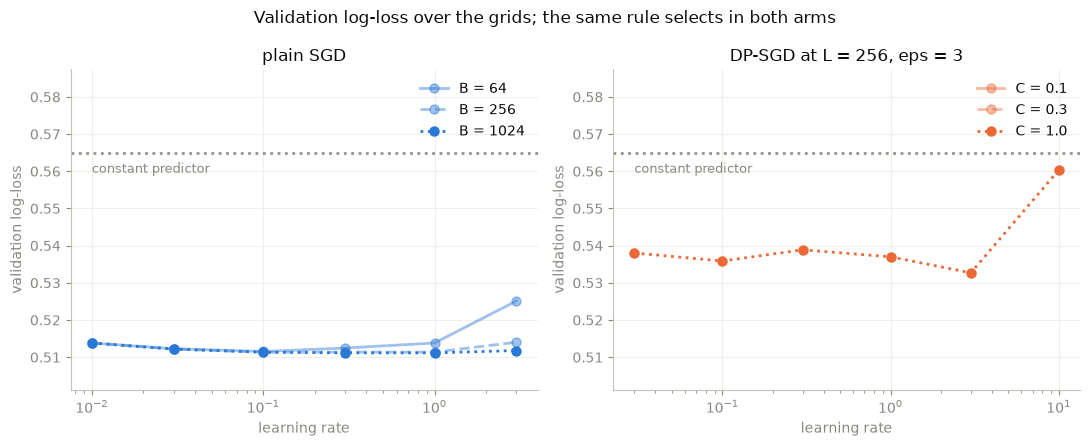

In [9]:
# What a model that ranks nothing scores. Also the denominator normalized
# entropy divides out, so it is the natural top of this axis.
CONST_VAL_LOSS = log_loss(np.full_like(Y_VAL_NP, float(Y_VAL_NP.mean())),
                          Y_VAL_NP)
best_loss = min(r["loss"] for r in sgd_sweep + dp_sweep
                if np.isfinite(r["loss"]))

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))

for batch in SGD_BATCH_GRID:
    rows = [r for r in sgd_sweep if r["batch"] == batch]
    left.plot([r["lr"] for r in rows], [r["loss"] for r in rows],
              marker="o", label=f"B = {batch}",
              alpha=0.45 + 0.55 * (batch == BEST_SGD["batch"]),
              color=SERIES["plain SGD"],
              linestyle=["-", "--", ":"][SGD_BATCH_GRID.index(batch)])

for clip in DP_CLIP_GRID:
    rows = [r for r in dp_sweep
            if r["clip"] == clip and r["batch"] == BEST_DP["batch"]]
    right.plot([r["lr"] for r in rows], [r["loss"] for r in rows],
               marker="o", label=f"C = {clip}",
               alpha=0.45 + 0.55 * (clip == BEST_DP["clip"]),
               color=SERIES["DP-SGD"],
               linestyle=["-", "--", ":"][DP_CLIP_GRID.index(clip)])

for axis, title, grid in (
        (left, "plain SGD", SGD_LR_GRID),
        (right, f"DP-SGD at L = {BEST_DP['batch']}, "
                f"eps = {TARGET_EPSILON:g}", DP_LR_GRID)):
    axis.axhline(CONST_VAL_LOSS, color=MUTED, linestyle=":", alpha=0.9)
    axis.annotate("constant predictor", xy=(grid[0], CONST_VAL_LOSS),
                  xytext=(0, -14), textcoords="offset points", color=MUTED,
                  fontsize=9)
    axis.set_xscale("log")
    axis.set_ylim(best_loss - 0.01, CONST_VAL_LOSS * 1.04)
    axis.set_xlabel("learning rate")
    axis.set_ylabel("validation log-loss")
    axis.set_title(title)
    axis.legend()
    axis.grid(alpha=0.5)

fig.suptitle("Validation log-loss over the grids; the same rule selects in "
             "both arms", color=INK)
fig.tight_layout()
plt.show()

## 5. Loss over steps, both arms, same axis

The trajectory is assembled from outside the inner loop, by calling `train` in
**40 chunks of 250 steps** and threading the parameters, the numpy sampling
stream and a per-chunk JAX key through, evaluating between chunks; the loop
itself is never reimplemented. The optimizer state and the epoch stream restart
at each chunk boundary, which is harmless without momentum, and the privacy
analysis is unchanged: still 10,000 Poisson-sampled Gaussian releases at the
calibrated σ.

Both curves are read on the same two fixed sets: a 100,000-row subsample of the
training rows, and the validation split.

In [10]:
CHUNKS = 40
CHUNK_STEPS = STEPS // CHUNKS
assert CHUNKS * CHUNK_STEPS == STEPS

# A fixed subsample of the training rows, drawn once, used by both arms.
curve_index = jnp.asarray(
    np.random.default_rng(BASE_SEED + 1).choice(n_train, 100_000,
                                                replace=False))
X_CURVE, Y_CURVE = X_TRAIN[curve_index], Y_TRAIN[curve_index]


def curve_point(params):
    """The four numbers recorded between chunks.

    Two arms, one trajectory each, so the calibration series is a real
    history rather than a set of independent runs read side by side.
    """
    train = evaluate_at(params, X_CURVE, Y_CURVE)
    val = evaluate_at(params, X_VAL, Y_VAL)
    return train.loss, val.loss, val.pr_auc, val.ece


def run_with_curve(arm):
    """`STEPS` steps in `CHUNKS` chunks, recording between them."""
    params = fresh_params()
    rng = np.random.default_rng([BASE_SEED, 0])
    record = [(0,) + curve_point(params)]
    for chunk in range(CHUNKS):
        if arm == "plain SGD":
            params, rng = fit_sgd(learning_rate=BEST_SGD["lr"],
                                  batch_size=BEST_SGD["batch"],
                                  steps=CHUNK_STEPS, params=params, rng=rng)
        else:
            params, rng = fit_dp_sgd(learning_rate=BEST_DP["lr"],
                                     expected_batch_size=BEST_DP["batch"],
                                     clip_norm=BEST_DP["clip"],
                                     noise_multiplier=SIGMA[BEST_DP["batch"]],
                                     steps=CHUNK_STEPS, chunk=chunk,
                                     params=params, rng=rng)
        record.append(((chunk + 1) * CHUNK_STEPS,) + curve_point(params))
    return params, record


FINAL, CURVE = {}, {}
for arm in ("plain SGD", "DP-SGD"):
    t0 = time.time()
    FINAL[arm], CURVE[arm] = run_with_curve(arm)
    last = CURVE[arm][-1]
    print(f"{arm:<10} {STEPS:,} steps in {time.time() - t0:5.0f}s   "
          f"train loss={last[1]:.4f}  val loss={last[2]:.4f}  "
          f"val PR-AUC={last[3]:.4f}  val ECE={last[4]:.4f}")

plain SGD  10,000 steps in    21s   train loss=0.5120  val loss=0.5112  val PR-AUC=0.4506  val ECE=0.0056


DP-SGD     10,000 steps in    64s   train loss=0.5398  val loss=0.5388  val PR-AUC=0.4503  val ECE=0.0699


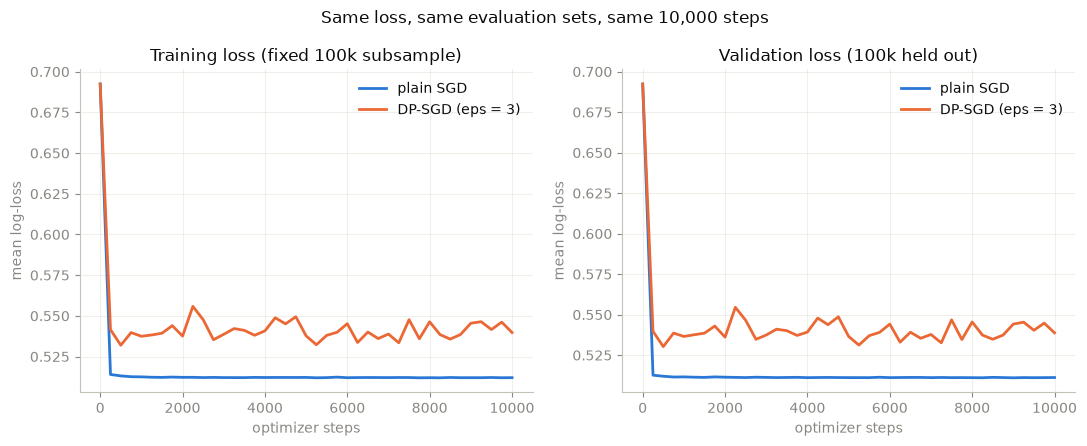

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))

for arm in ("plain SGD", "DP-SGD"):
    steps_axis = [p[0] for p in CURVE[arm]]
    label = arm if arm == "plain SGD" else (
        f"DP-SGD (eps = {TARGET_EPSILON:g})")
    left.plot(steps_axis, [p[1] for p in CURVE[arm]], color=SERIES[arm],
              label=label)
    right.plot(steps_axis, [p[2] for p in CURVE[arm]], color=SERIES[arm],
               label=label)

for axis, title, ylabel in (
        (left, "Training loss (fixed 100k subsample)", "mean log-loss"),
        (right, "Validation loss (100k held out)", "mean log-loss")):
    axis.set_xlabel("optimizer steps")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.legend()
    axis.grid(alpha=0.5)

fig.suptitle(f"Same loss, same evaluation sets, same {STEPS:,} steps",
             color=INK)
fig.tight_layout()
plt.show()

Ranking quality and calibration over the same steps: the loss can still be
falling while the ordering has stopped improving.

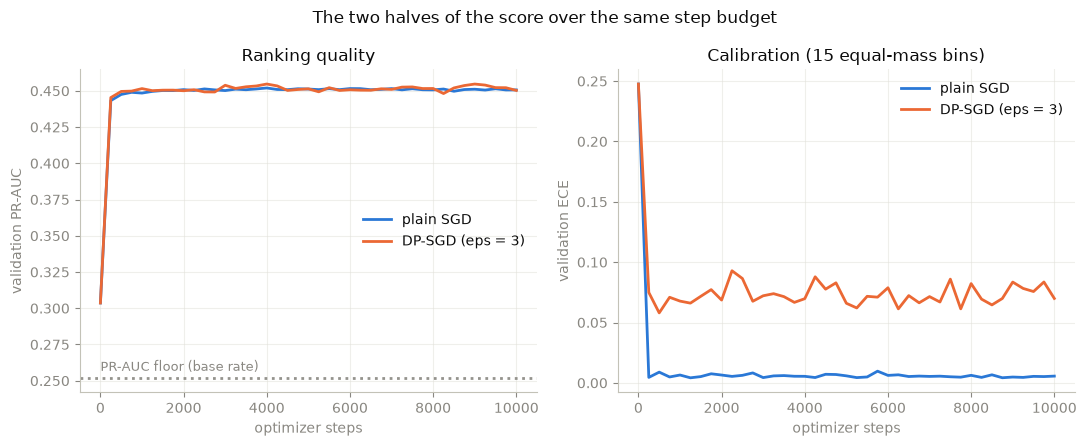

In [12]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))

for arm in ("plain SGD", "DP-SGD"):
    label = arm if arm == "plain SGD" else f"DP-SGD (eps = {TARGET_EPSILON:g})"
    steps_axis = [p[0] for p in CURVE[arm]]
    left.plot(steps_axis, [p[3] for p in CURVE[arm]], color=SERIES[arm],
              label=label)
    right.plot(steps_axis, [p[4] for p in CURVE[arm]], color=SERIES[arm],
               label=label)

left.axhline(base_rate, color=MUTED, linestyle=":", alpha=0.9)
left.annotate("PR-AUC floor (base rate)", xy=(0, base_rate), xytext=(0, 5),
              textcoords="offset points", color=MUTED, fontsize=9)

for axis, title, ylabel in (
        (left, "Ranking quality", "validation PR-AUC"),
        (right, f"Calibration ({N_BINS} equal-mass bins)",
         "validation ECE")):
    axis.set_xlabel("optimizer steps")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.legend()
    axis.grid(alpha=0.5)

fig.suptitle("The two halves of the score over the same step budget",
             color=INK)
fig.tight_layout()
plt.show()

## 6. The operating point, then the test split

A confusion matrix is a quantity at a threshold, and the threshold is set by
**one rule applied identically to both models: the cut that maximises F1 on the
validation split.** It is chosen per model, and frozen before the test split is
read.

In [13]:
THRESHOLD, VAL_F1 = {}, {}
for arm in ("plain SGD", "DP-SGD"):
    probs = probabilities(scores(FINAL[arm], X_VAL))
    THRESHOLD[arm], VAL_F1[arm] = best_f1_threshold(probs, Y_VAL_NP)
    print(f"{arm:<10} validation-optimal threshold p >= {THRESHOLD[arm]:.4f}"
          f"   val F1 = {VAL_F1[arm]:.4f}")

plain SGD  validation-optimal threshold p >= 0.2379   val F1 = 0.4909
DP-SGD     validation-optimal threshold p >= 0.1529   val F1 = 0.4898


Now, and only now, the test split.

In [14]:
Y_TEST_NP = np.asarray(Y_TEST, dtype=np.float64)
TEST = {}

for arm in ("plain SGD", "DP-SGD"):
    probs = probabilities(scores(FINAL[arm], X_TEST))
    curve = pr_curve(probs, Y_TEST_NP)
    cm = confusion_at(probs, Y_TEST_NP, THRESHOLD[arm])
    tn, fp, fn, tp = cm
    TEST[arm] = dict(
        probs=probs, precision_curve=curve.precision,
        recall_curve=curve.recall,
        pr_auc=curve.average_precision, loss=log_loss(probs, Y_TEST_NP),
        ne=normalized_entropy(probs, Y_TEST_NP),
        ece=expected_calibration_error(probs, Y_TEST_NP, n_bins=N_BINS),
        cal_ratio=calibration_ratio(probs, Y_TEST_NP), confusion=cm,
        tpr=tp / (tp + fn), precision_at=tp / (tp + fp) if tp + fp else np.nan,
    )

# The threshold-free scores first: these are properties of the model.
CONST = np.full_like(Y_TEST_NP, base_rate)
print(f"{'':<12}{'log-loss':>10}{'NE':>8}{'ECE':>8}{'cal-ratio':>11}"
      f"{'PR-AUC':>9}")
print(f"{'constant':<12}{log_loss(CONST, Y_TEST_NP):10.4f}"
      f"{normalized_entropy(CONST, Y_TEST_NP):8.4f}"
      f"{expected_calibration_error(CONST, Y_TEST_NP, n_bins=N_BINS):8.4f}"
      f"{calibration_ratio(CONST, Y_TEST_NP):11.4f}{base_rate:9.4f}")
for arm in ("plain SGD", "DP-SGD"):
    r = TEST[arm]
    print(f"{arm:<12}{r['loss']:10.4f}{r['ne']:8.4f}{r['ece']:8.4f}"
          f"{r['cal_ratio']:11.4f}{r['pr_auc']:9.4f}")

# Then the operating point, which is a choice rather than a property.
print(f"\n{'':<12}{'TPR':>9}{'precision':>11}{'F1':>8}{'threshold':>11}")
for arm in ("plain SGD", "DP-SGD"):
    r = TEST[arm]
    f1 = 2 * r["precision_at"] * r["tpr"] / (r["precision_at"] + r["tpr"])
    print(f"{arm:<12}{r['tpr']:9.4f}{r['precision_at']:11.4f}{f1:8.4f}"
          f"{THRESHOLD[arm]:11.4f}")

print(f"\nDP-SGD at epsilon = {TARGET_EPSILON:g}, delta = {TARGET_DELTA}, "
      f"RDP accounting, over {STEPS:,} steps.")
print("plain SGD carries no epsilon: it is the unbounded-leakage end of the axis.")

              log-loss      NE     ECE  cal-ratio   PR-AUC
constant        0.5645  1.0000  0.0000     1.0000   0.2520
plain SGD       0.5123  0.9076  0.0051     1.0169   0.4462
DP-SGD          0.5402  0.9570  0.0705     1.3703   0.4456

                  TPR  precision      F1  threshold
plain SGD      0.6715     0.3831  0.4879     0.2379
DP-SGD         0.6622     0.3862  0.4879     0.1529

DP-SGD at epsilon = 3, delta = 1e-06, RDP accounting, over 10,000 steps.
plain SGD carries no epsilon: it is the unbounded-leakage end of the axis.


In [15]:
for arm in ("plain SGD", "DP-SGD"):
    show_confusion(TEST[arm]["confusion"], f"{arm} on the test split",
                   THRESHOLD[arm])
    print()

plain SGD on the test split
                 predicted no    predicted click
  actual no            95,105             54,495
  actual click         16,557             33,843
  precision 0.3831   TPR (recall) 0.6715   (at threshold p >= 0.2379)

DP-SGD on the test split
                 predicted no    predicted click
  actual no            96,567             53,033
  actual click         17,025             33,375
  precision 0.3862   TPR (recall) 0.6622   (at threshold p >= 0.1529)



The test precision–recall curves with PR-AUC in the legend, the base rate as
the floor a random ranking would reach, and each model's chosen operating point
marked.

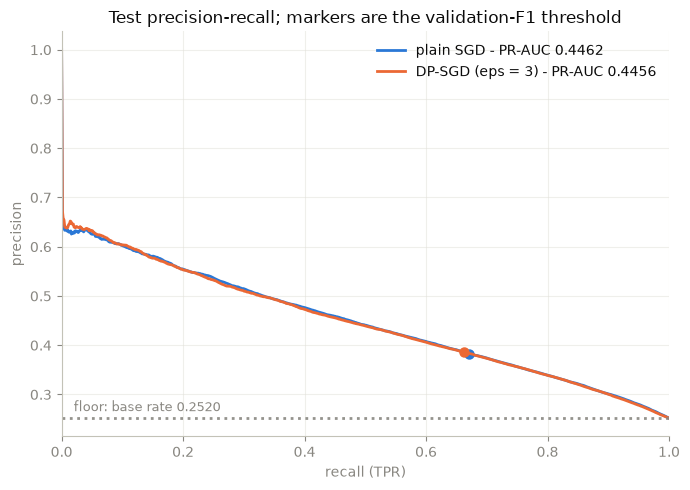

In [16]:
fig, axis = plt.subplots(figsize=(7, 5))

for arm in ("plain SGD", "DP-SGD"):
    r = TEST[arm]
    # ~2000 points is plenty for a 200k-row curve and keeps the file small.
    stride = max(1, len(r["recall_curve"]) // 2000)
    label = (f"{arm} - PR-AUC {r['pr_auc']:.4f}" if arm == "plain SGD" else
             f"{arm} (eps = {TARGET_EPSILON:g}) - PR-AUC {r['pr_auc']:.4f}")
    axis.plot(r["recall_curve"][::stride], r["precision_curve"][::stride],
              color=SERIES[arm], label=label)
    axis.plot([r["tpr"]], [r["precision_at"]], marker="o", color=SERIES[arm],
              linestyle="none")

axis.axhline(base_rate, color=MUTED, linestyle=":", alpha=0.9)
axis.annotate(f"floor: base rate {base_rate:.4f}", xy=(0.02, base_rate),
              xytext=(0, 5), textcoords="offset points", color=MUTED,
              fontsize=9)
axis.set_xlabel("recall (TPR)")
axis.set_ylabel("precision")
axis.set_xlim(0, 1)
axis.set_title("Test precision-recall; markers are the validation-F1 threshold")
axis.legend(loc="upper right")
axis.grid(alpha=0.5)
fig.tight_layout()
plt.show()

The same two operating points as matrices, side by side and on a shared count
scale, so the difference is read in records rather than in rates.

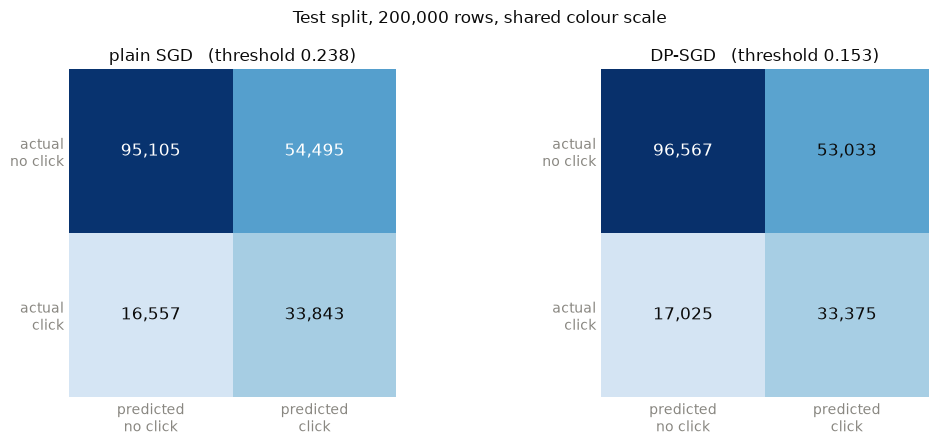

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["no click", "click"]
shared_max = max(max(TEST[arm]["confusion"]) for arm in TEST)

for axis, arm in zip(axes, ("plain SGD", "DP-SGD")):
    tn, fp, fn, tp = TEST[arm]["confusion"]
    grid = np.array([[tn, fp], [fn, tp]])
    axis.imshow(grid, cmap="Blues", vmin=0, vmax=shared_max)
    for i in range(2):
        for j in range(2):
            axis.text(j, i, f"{grid[i, j]:,}", ha="center", va="center",
                      fontsize=12,
                      color="white" if grid[i, j] > shared_max * 0.55 else INK)
    axis.set_xticks([0, 1], [f"predicted\n{lab}" for lab in labels])
    axis.set_yticks([0, 1], [f"actual\n{lab}" for lab in labels])
    axis.set_title(f"{arm}   (threshold {THRESHOLD[arm]:.3f})")
    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.tick_params(length=0)
    axis.grid(False)

fig.suptitle(f"Test split, {len(Y_TEST_NP):,} rows, shared colour scale",
             color=INK)
fig.tight_layout()
plt.show()

### Calibration, measured rather than inferred

The reliability curve here and the decomposition below read calibration
directly, rather than inferring it from the scores above.

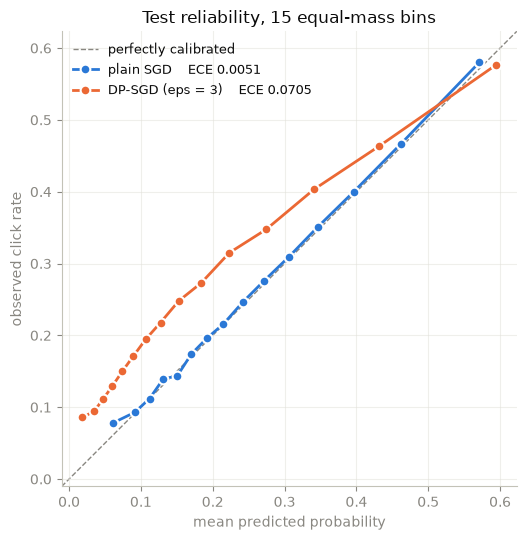

plain SGD  15 bins kept, 13,333-13,334 records each, largest gap -0.0169 (predicted - observed)
DP-SGD     15 bins kept, 13,333-13,334 records each, largest gap -0.0953 (predicted - observed)


In [18]:
RELIABILITY = {arm: reliability_curve(TEST[arm]["probs"], Y_TEST_NP,
                                     n_bins=N_BINS)
               for arm in ("plain SGD", "DP-SGD")}

points = np.concatenate([np.concatenate([c.mean_predicted, c.mean_observed])
                         for c in RELIABILITY.values()])
pad = 0.05 * (points.max() - points.min())
lo, hi = points.min() - pad, points.max() + pad

fig, axis = plt.subplots(figsize=(5.5, 5.5))
axis.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color=MUTED,
          zorder=1, label="perfectly calibrated")

# Identity is in the legend rather than at the end of each line: the two
# curves are expected to sit almost on top of each other and on the diagonal,
# which is where a direct label stops being readable.
for arm in ("plain SGD", "DP-SGD"):
    curve = RELIABILITY[arm]
    name = arm if arm == "plain SGD" else f"DP-SGD (eps = {TARGET_EPSILON:g})"
    axis.plot(curve.mean_predicted, curve.mean_observed, marker="o",
              markersize=7, linewidth=2, color=SERIES[arm], zorder=2,
              markeredgecolor="white", markeredgewidth=1.5,
              label=f"{name}    ECE {TEST[arm]['ece']:.4f}")

axis.set_xlim(lo, hi)
axis.set_ylim(lo, hi)
axis.set_aspect("equal")
axis.set_xlabel("mean predicted probability")
axis.set_ylabel("observed click rate")
axis.set_title(f"Test reliability, {N_BINS} equal-mass bins", color=INK)
axis.grid(alpha=0.5)
axis.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

for arm in ("plain SGD", "DP-SGD"):
    curve = RELIABILITY[arm]
    worst = curve.gap[int(np.argmax(np.abs(curve.gap)))]
    print(f"{arm:<10} {len(curve.count)} bins kept, "
          f"{curve.count.min():,}-{curve.count.max():,} records each, "
          f"largest gap {worst:+.4f} (predicted - observed)")

The same thing as numbers: `log-loss = calibration - resolution + uncertainty +
residual`, at the same bins. A log-loss gap that sits in the calibration term
is the claim the closing section makes; one that sat in resolution would
falsify it.

In [19]:
DECOMPOSITION = {arm: log_loss_decomposition(TEST[arm]["probs"], Y_TEST_NP,
                                            n_bins=N_BINS)
                 for arm in ("plain SGD", "DP-SGD")}

print(f"{'':<12}{'calibration':>13}{'resolution':>12}{'uncertainty':>13}"
      f"{'residual':>10}{'log-loss':>10}")
for arm in ("plain SGD", "DP-SGD"):
    d = DECOMPOSITION[arm]
    print(f"{arm:<12}{d.calibration:13.4f}{d.resolution:12.4f}"
          f"{d.uncertainty:13.4f}{d.residual:10.4f}{d.total:10.4f}")

baseline, private = DECOMPOSITION["plain SGD"], DECOMPOSITION["DP-SGD"]
print(f"\n{'private - baseline':<12}")
print(f"  calibration {private.calibration - baseline.calibration:+.4f}   "
      f"resolution {private.resolution - baseline.resolution:+.4f}   "
      f"residual {private.residual - baseline.residual:+.4f}   "
      f"->  log-loss {private.total - baseline.total:+.4f}")

              calibration  resolution  uncertainty  residual  log-loss
plain SGD          0.0002      0.0522       0.5645   -0.0002    0.5123
DP-SGD             0.0267      0.0514       0.5645    0.0004    0.5402

private - baseline
  calibration +0.0265   resolution -0.0008   residual +0.0006   ->  log-loss +0.0279


## 7. Does the gap survive a change of seed?

The selected configuration of each arm is re-run at three seeds: the
initialization stays `jax.random.key(0)`, and what varies is the sampling
stream and, in the private arm, the noise. These are monolithic 10,000-step
runs rather than the chunked ones from section 5.

Three seeds is a spread, not a confidence interval. It is reported as min/max.

In [20]:
REPEATS = {}
t0 = time.time()
for arm in ("plain SGD", "DP-SGD"):
    values = []
    for seed_index in (0, 1, 2):
        if arm == "plain SGD":
            params, _ = fit_sgd(learning_rate=BEST_SGD["lr"],
                                batch_size=BEST_SGD["batch"],
                                seed_index=1000 + seed_index)
        else:
            params, _ = fit_dp_sgd(learning_rate=BEST_DP["lr"],
                                   expected_batch_size=BEST_DP["batch"],
                                   clip_norm=BEST_DP["clip"],
                                   noise_multiplier=SIGMA[BEST_DP["batch"]],
                                   seed_index=1000 + seed_index)
        values.append(evaluate_at(params, X_TEST, Y_TEST))
    REPEATS[arm] = values
    losses = [v.loss for v in values]
    prs = [v.pr_auc for v in values]
    eces = [v.ece for v in values]
    print(f"{arm:<10} test log-loss {np.mean(losses):.4f} "
          f"[{min(losses):.4f}, {max(losses):.4f}]   "
          f"PR-AUC {np.mean(prs):.4f} [{min(prs):.4f}, {max(prs):.4f}]   "
          f"ECE {np.mean(eces):.4f} [{min(eces):.4f}, {max(eces):.4f}]   "
          f"(chunked run: {TEST[arm]['loss']:.4f} / "
          f"{TEST[arm]['pr_auc']:.4f} / {TEST[arm]['ece']:.4f})")


def gap_of(field):
    """Baseline minus private: at the means, and at the two extremes."""
    base = [getattr(v, field) for v in REPEATS["plain SGD"]]
    private = [getattr(v, field) for v in REPEATS["DP-SGD"]]
    return (float(np.mean(base)) - float(np.mean(private)),
            min(base) - max(private), max(base) - min(private))


print()
for field, name in (("pr_auc", "PR-AUC"), ("loss", "log-loss"),
                    ("ece", "ECE")):
    mean_gap, low, high = gap_of(field)
    print(f"{name:>9} gap (baseline - private): mean {mean_gap:+.4f}, "
          f"range [{low:+.4f}, {high:+.4f}] over 3 seeds")
print(f"\n({time.time() - t0:.0f}s)")

plain SGD  test log-loss 0.5124 [0.5123, 0.5124]   PR-AUC 0.4464 [0.4459, 0.4469]   ECE 0.0042 [0.0033, 0.0052]   (chunked run: 0.5123 / 0.4462 / 0.0051)


DP-SGD     test log-loss 0.5436 [0.5385, 0.5465]   PR-AUC 0.4485 [0.4480, 0.4490]   ECE 0.0775 [0.0694, 0.0821]   (chunked run: 0.5402 / 0.4456 / 0.0705)

   PR-AUC gap (baseline - private): mean -0.0020, range [-0.0032, -0.0011] over 3 seeds
 log-loss gap (baseline - private): mean -0.0313, range [-0.0342, -0.0261] over 3 seeds
      ECE gap (baseline - private): mean -0.0733, range [-0.0787, -0.0642] over 3 seeds

(144s)


## What this shows, and what it does not

Both arms descend the same loss on the same 700,000 rows, from the same
initialization, for the same 10,000 steps, each at the configuration the same
rule selected on validation. The private arm additionally clips every
per-sample gradient to `C` and adds Gaussian noise at the multiplier
calibrated for ε = 3, δ = 1e-6 over exactly those steps.

At this budget **the ranking cost is not measurable and the calibration cost
is.** Test PR-AUC is 0.4462 for the baseline and 0.4456 for the private arm,
against a base-rate floor of 0.2520 — and that gap changes sign in section 7,
where the private arm's three-seed mean lands *above* the baseline's, 0.4485
against 0.4464. The two arms cannot be separated on ranking here. Test
log-loss is 0.5123 against 0.5402, and the decomposition puts that 0.0279 in
the calibration term (+0.0265) rather than in resolution (−0.0008).

At the F1 operating point the private model catches 468 fewer clicks (33,375
against 33,843) and raises 1,462 fewer false alarms (53,033 against 54,495),
at the same F1 of 0.4879.

Not shown, and not claimed:

- The preprocessing statistics and the 54-run search are unaccounted, so the
  reported ε covers the selected run only.
- Three seeds is a spread, not an error bar.
- One budget, one dataset, one model: logistic regression on Criteo at ε = 3.
- The ε is RDP's (ADR-0011); PLD would report a smaller one for the same run.